
## Fase 5 — Agregación por localidad y construcción de H1′

## Configuración

In [1]:
from pathlib import Path
import unicodedata
import re
import warnings

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

np.random.seed(2026)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path("../..")

RUTAS = {
    "encuesta": PROJECT_ROOT / "outputs" / "encuesta_percepcion_legible.csv",
    "linea_purpura": PROJECT_ROOT / "outputs" / "lineapurpura.csv",
    "duplas": PROJECT_ROOT / "outputs" / "duplas.csv",
    "riesgo_feminicidio": PROJECT_ROOT / "outputs" / "riesgofeminicidio.csv",
}

RUTA_SUPUESTOS = Path("../../docs/supuestos.md")
RUTA_SUPUESTOS.parent.mkdir(parents=True, exist_ok=True)

for nombre, ruta in RUTAS.items():
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró '{nombre}': {ruta}")

print("Configuración cargada correctamente.")

Configuración cargada correctamente.


In [2]:
def registrar_resultado(texto):
    with open(RUTA_SUPUESTOS, "a", encoding="utf-8") as f:
        f.write("\n" + texto.strip() + "\n")

def leer_csv_robusto(path):
    errores = []

    for encoding in ("utf-8-sig", "utf-8", "latin-1", "cp1252"):
        try:
            return pd.read_csv(
                path,
                sep=None,
                engine="python",
                encoding=encoding
            )
        except Exception as e:
            errores.append((encoding, str(e)))

    raise RuntimeError(
        f"No fue posible leer {path.name}. Intentos: {errores}"
    )

encuesta = leer_csv_robusto(RUTAS["encuesta"])
linea_purpura = leer_csv_robusto(RUTAS["linea_purpura"])
duplas = leer_csv_robusto(RUTAS["duplas"])
riesgo = leer_csv_robusto(RUTAS["riesgo_feminicidio"])

print("Fuentes cargadas correctamente.")

Fuentes cargadas correctamente.


## 5.1 — Indicadores poblacionales por localidad

In [3]:
# ============================================================
# PASO 5.1 — Validación de columnas y estructura de la encuesta
# ============================================================

COLUMNAS_ENCUESTA = [
    "codigo_localidad",
    "codigo_UPL",
    "fexp_calp_anu",
    "fexp_calh_anu",
    "D1",
    "sexo_jefe",
    "C303",
    "ind_salud_102",
    "IPSJ_A",
    "IPSJ_C",
    "IPSJ_E",
    "ICG_B",
    "Mx404_1",
    "Mx404_2",
    "Mx404_3",
    "Mx404_4",
    "Mx404_5",
    "Mx404_6",
    "Ax201",
    "Bx201",
    "Cx201",
    "Dx201",
    "Ex201",
    "Fx201",
    "Gx201",
    "Hx201",
    "Ix201",
    "Jx201",
]


# ------------------------------------------------------------
# 1. Verificar presencia de columnas requeridas
# ------------------------------------------------------------

faltantes = [
    columna
    for columna in COLUMNAS_ENCUESTA
    if columna not in encuesta.columns
]

assert not faltantes, (
    "Faltan columnas requeridas en la encuesta: "
    f"{faltantes}"
)


# ------------------------------------------------------------
# 2. Normalizar codigo_localidad
# ------------------------------------------------------------

encuesta["codigo_localidad"] = pd.to_numeric(
    encuesta["codigo_localidad"],
    errors="raise"
).astype(int)


# ------------------------------------------------------------
# 3. Normalizar codigo_UPL
#
# Formato observado:
#   UPL03
#   UPL07
#   UPL21
#
# Se conserva codigo_UPL original y se crea codigo_UPL_num
# para operaciones numéricas cuando sea necesario.
# ------------------------------------------------------------

encuesta["codigo_UPL"] = (
    encuesta["codigo_UPL"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Validar estructura UPL + número
mask_upl_valida = encuesta["codigo_UPL"].str.match(
    r"^UPL\d+$",
    na=False
)

if not mask_upl_valida.all():
    valores_invalidos = (
        encuesta.loc[
            ~mask_upl_valida,
            "codigo_UPL"
        ]
        .drop_duplicates()
        .tolist()
    )

    raise ValueError(
        "Se encontraron códigos UPL con formato inesperado: "
        f"{valores_invalidos[:20]}"
    )


# Extraer únicamente la parte numérica
encuesta["codigo_UPL_num"] = (
    encuesta["codigo_UPL"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)


# ------------------------------------------------------------
# 4. Validar estructura esperada de la fuente
# ------------------------------------------------------------

assert len(encuesta) == 13082, (
    "Número de registros inesperado. "
    f"Esperados: 13.082 | Encontrados: {len(encuesta):,}"
)

n_localidades = encuesta["codigo_localidad"].nunique()

assert n_localidades == 19, (
    "Número de localidades inesperado. "
    f"Esperadas: 19 | Encontradas: {n_localidades}"
)

n_upl = encuesta["codigo_UPL"].nunique()

assert n_upl == 30, (
    "Número de UPL inesperado. "
    f"Esperadas: 30 | Encontradas: {n_upl}"
)

assert encuesta["codigo_localidad"].between(1, 19).all(), (
    "Se encontraron códigos de localidad fuera del rango 1–19."
)


# ------------------------------------------------------------
# 5. Validar relación entre código textual y numérico de UPL
# ------------------------------------------------------------

assert encuesta["codigo_UPL_num"].nunique() == 30, (
    "La extracción numérica de codigo_UPL no produjo "
    "las 30 UPL esperadas."
)

assert encuesta["codigo_UPL_num"].notna().all(), (
    "Se generaron valores nulos al extraer el número de UPL."
)


# ------------------------------------------------------------
# 6. Validar factores de expansión
# ------------------------------------------------------------

for columna_peso in [
    "fexp_calp_anu",
    "fexp_calh_anu"
]:
    encuesta[columna_peso] = pd.to_numeric(
        encuesta[columna_peso],
        errors="coerce"
    )

    assert encuesta[columna_peso].notna().all(), (
        f"Se encontraron valores nulos o no numéricos "
        f"en {columna_peso}."
    )

    assert (encuesta[columna_peso] > 0).all(), (
        f"Se encontraron factores de expansión no positivos "
        f"en {columna_peso}."
    )


# ------------------------------------------------------------
# 7. Resultado de validación
# ------------------------------------------------------------

print("Validación de la Encuesta de Percepción completada.")
print(f"Registros: {len(encuesta):,}")
print(f"Localidades: {n_localidades}")
print(f"UPL: {n_upl}")
print(f"Columnas requeridas verificadas: {len(COLUMNAS_ENCUESTA)}")
print("Factores de expansión: válidos y positivos.")

print("\nEjemplo de codificación UPL:")
print(
    encuesta[
        ["codigo_UPL", "codigo_UPL_num"]
    ]
    .drop_duplicates()
    .sort_values("codigo_UPL_num")
    .head(10)
    .to_string(index=False)
)

Validación de la Encuesta de Percepción completada.
Registros: 13,082
Localidades: 19
UPL: 30
Columnas requeridas verificadas: 28
Factores de expansión: válidos y positivos.

Ejemplo de codificación UPL:
codigo_UPL  codigo_UPL_num
     UPL03               3
     UPL04               4
     UPL05               5
     UPL07               7
     UPL08               8
     UPL09               9
     UPL10              10
     UPL11              11
     UPL12              12
     UPL13              13


In [4]:
cols_m_1a5 = [f"Mx404_{i}" for i in range(1, 6)]

encuesta["afronto_M"] = (
    encuesta[cols_m_1a5].eq("Si").any(axis=1)
).astype(int)

inconsistencia_404 = (
    encuesta["afronto_M"]
    != encuesta["Mx404_6"].eq("No").astype(int)
).sum()

componentes_iba = ["IPSJ_A", "IPSJ_C", "IPSJ_E"]
mask_iba = encuesta[componentes_iba].notna().all(axis=1)

encuesta["IBA"] = np.nan
z_componentes = []

for col in componentes_iba:
    serie = pd.to_numeric(encuesta.loc[mask_iba, col], errors="coerce")
    z = (serie - serie.mean()) / serie.std(ddof=0)
    z_componentes.append(z)

encuesta.loc[mask_iba, "IBA"] = -(
    z_componentes[0] + z_componentes[1] + z_componentes[2]
) / 3

categorias_gad_severas = {
    "Se aprecian síntomas de ansiedad moderados",
    "Se aprecian síntomas de ansiedad severos",
}

encuesta["gad7_mod_sev"] = (
    encuesta["ind_salud_102"].isin(categorias_gad_severas)
).astype(int)

encuesta["pobreza_subjetiva"] = (
    encuesta["C303"].eq("Si")
).astype(int)

In [5]:
TAREAS = [
    "Ax201", "Bx201", "Cx201", "Dx201", "Ex201",
    "Fx201", "Gx201", "Hx201", "Ix201", "Jx201"
]

def calcular_icc_fila(row):
    respuestas = [
        row[c] for c in TAREAS
        if pd.notna(row[c]) and row[c] != "No se realiza"
    ]

    n_tareas = len(respuestas)

    if n_tareas < 5:
        return pd.Series(
            [np.nan, np.nan, np.nan, np.nan],
            index=[
                "HHI",
                "responsable_principal",
                "sexo_responsable_principal",
                "ICC_mujer",
            ],
        )

    conteos = pd.Series(respuestas).value_counts()
    proporciones = conteos / n_tareas
    hhi = float((proporciones ** 2).sum())
    responsable = conteos.idxmax()

    sexo = np.nan

    if responsable == "El /la jefe/a de hogar":
        if row["sexo_jefe"] in {"Mujer", "Hombre"}:
            sexo = row["sexo_jefe"]

    elif responsable == "El/la cónyuge o pareja del jefe de hogar":
        if row["sexo_jefe"] == "Hombre":
            sexo = "Mujer"
        elif row["sexo_jefe"] == "Mujer":
            sexo = "Hombre"

    icc_mujer = hhi if sexo == "Mujer" else 0.0

    return pd.Series(
        [hhi, responsable, sexo, icc_mujer],
        index=[
            "HHI",
            "responsable_principal",
            "sexo_responsable_principal",
            "ICC_mujer",
        ],
    )

icc = encuesta.apply(calcular_icc_fila, axis=1)
encuesta = pd.concat([encuesta, icc], axis=1)

encuesta["carga_concentrada_mujer"] = (
    encuesta["ICC_mujer"] >= 0.50
).astype("Int64")

In [6]:
def estadistico_ponderado(data, variable, peso, grupo="codigo_localidad"):
    filas = []

    for codigo, g in data.groupby(grupo):
        sub = g[[variable, peso]].dropna().copy()

        x = pd.to_numeric(sub[variable], errors="coerce")
        w = pd.to_numeric(sub[peso], errors="coerce")

        valid = x.notna() & w.notna() & (w > 0)
        x = x[valid].to_numpy(dtype=float)
        w = w[valid].to_numpy(dtype=float)

        n = len(x)

        if n == 0:
            filas.append({
                grupo: codigo,
                "estimacion": np.nan,
                "se": np.nan,
                "ic_inf": np.nan,
                "ic_sup": np.nan,
                "n": 0,
                "n_eff": 0,
                "cv_pct": np.nan,
            })
            continue

        estimacion = np.average(x, weights=w)
        n_eff = (w.sum() ** 2) / np.square(w).sum()
        var_pond = np.average(np.square(x - estimacion), weights=w)
        se = np.sqrt(var_pond / n_eff) if n_eff > 0 else np.nan

        filas.append({
            grupo: codigo,
            "estimacion": estimacion,
            "se": se,
            "ic_inf": estimacion - 1.96 * se,
            "ic_sup": estimacion + 1.96 * se,
            "n": n,
            "n_eff": n_eff,
            "cv_pct": abs(se / estimacion) * 100
            if np.isfinite(estimacion) and estimacion != 0
            else np.nan,
        })

    return pd.DataFrame(filas)

def extraer_indicador(data, variable, peso, prefijo):
    out = estadistico_ponderado(data, variable, peso)

    return out.rename(columns={
        "estimacion": prefijo,
        "se": f"{prefijo}_se",
        "ic_inf": f"{prefijo}_ic_inf",
        "ic_sup": f"{prefijo}_ic_sup",
        "n": f"{prefijo}_n",
        "n_eff": f"{prefijo}_n_eff",
        "cv_pct": f"{prefijo}_cv_pct",
    })

indicadores = pd.DataFrame({
    "codigo_localidad": sorted(encuesta["codigo_localidad"].unique())
})

especificaciones = [
    ("afronto_M", "fexp_calp_anu", "TAC_M"),
    ("carga_concentrada_mujer", "fexp_calh_anu", "pct_carga_mujer"),
    ("gad7_mod_sev", "fexp_calp_anu", "gad7_mod_sev"),
    ("pobreza_subjetiva", "fexp_calp_anu", "pobreza_subjetiva"),
    ("IPSJ_C", "fexp_calp_anu", "IPSJ_C_promedio"),
    ("ICG_B", "fexp_calp_anu", "ICG_B_promedio"),
    ("IBA", "fexp_calp_anu", "IBA_promedio"),
]

for variable, peso, prefijo in especificaciones:
    tabla = extraer_indicador(encuesta, variable, peso, prefijo)
    indicadores = indicadores.merge(
        tabla,
        on="codigo_localidad",
        how="left"
    )

encuesta["es_mujer"] = encuesta["D1"].eq("Mujer")
mujeres = encuesta[encuesta["es_mujer"]].copy()

pob_adulta_mujeres = (
    mujeres.groupby("codigo_localidad")["fexp_calp_anu"]
    .sum()
    .rename("pob_mujeres_adultas_expandida")
    .reset_index()
)

vol_min = (
    mujeres.loc[mujeres["afronto_M"] == 1]
    .groupby("codigo_localidad")["fexp_calp_anu"]
    .sum()
    .rename("vol_mujeres_visible_afrontada_min")
    .reset_index()
)

indicadores = (
    indicadores
    .merge(pob_adulta_mujeres, on="codigo_localidad", how="left")
    .merge(vol_min, on="codigo_localidad", how="left")
)

indicadores["vol_mujeres_visible_afrontada_min"] = (
    indicadores["vol_mujeres_visible_afrontada_min"].fillna(0)
)

upl_localidad = (
    encuesta.groupby("codigo_localidad")["codigo_UPL"]
    .nunique()
    .rename("n_UPL")
    .reset_index()
)

indicadores = indicadores.merge(
    upl_localidad,
    on="codigo_localidad",
    how="left"
)

tac_ciudad = np.average(
    encuesta["afronto_M"],
    weights=encuesta["fexp_calp_anu"]
)

texto_resultado_5_1 = f"""
## Paso 5.1 — Indicadores poblacionales por localidad ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultados**

- Registros analizados: **{len(encuesta):,}**.
- Localidades con información de encuesta: **{encuesta['codigo_localidad'].nunique()}**.
- UPL presentes: **{encuesta['codigo_UPL'].nunique()}**.
- TAC_M ponderada para Bogotá: **{tac_ciudad*100:.1f}%**.
- Mujeres adultas expandidas en las 19 localidades: **{indicadores['pob_mujeres_adultas_expandida'].sum():,.0f}**.
- Volumen expandido mínimo de mujeres con violencia visible y afrontada: **{indicadores['vol_mujeres_visible_afrontada_min'].sum():,.0f}**.
- Registros válidos para IBA: **{encuesta['IBA'].notna().sum():,}**.
- Registros válidos para ICC: **{encuesta['HHI'].notna().sum():,}**.
- Inconsistencias observadas entre Mx404_1..5 y Mx404_6: **{inconsistencia_404}**.

**Conclusión**

Al menos **{tac_ciudad*100:.1f}%** de la población representada por la encuesta presenció y afrontó una situación de violencia contra una mujer. Este valor constituye una cota inferior de la violencia socialmente visible y afrontada y no una estimación de prevalencia total.
"""

registrar_resultado(texto_resultado_5_1)
print("Resultado del Paso 5.1 guardado en ../../docs/supuestos.md")

Resultado del Paso 5.1 guardado en ../../docs/supuestos.md


## 5.2 — Criterio de publicación

In [7]:
INDICADORES_CV = [
    "TAC_M",
    "pct_carga_mujer",
    "gad7_mod_sev",
    "pobreza_subjetiva",
]

for prefijo in INDICADORES_CV:
    indicadores[f"{prefijo}_publicable"] = (
        (indicadores[f"{prefijo}_n_eff"] >= 30)
        & (indicadores[f"{prefijo}_cv_pct"] <= 30)
    )

for prefijo in [
    "IPSJ_C_promedio",
    "ICG_B_promedio",
    "IBA_promedio",
]:
    indicadores[f"{prefijo}_publicable"] = (
        indicadores[f"{prefijo}_n_eff"] >= 30
    )

indicadores["publicable_demanda_min"] = (
    indicadores["TAC_M_publicable"]
    & indicadores["vol_mujeres_visible_afrontada_min"].gt(0)
)

resumen_publicacion = pd.DataFrame({
    "indicador": [
        "TAC_M",
        "pct_carga_mujer",
        "gad7_mod_sev",
        "pobreza_subjetiva",
        "IPSJ_C_promedio",
        "ICG_B_promedio",
        "IBA_promedio",
    ],
    "localidades_publicables": [
        int(indicadores["TAC_M_publicable"].sum()),
        int(indicadores["pct_carga_mujer_publicable"].sum()),
        int(indicadores["gad7_mod_sev_publicable"].sum()),
        int(indicadores["pobreza_subjetiva_publicable"].sum()),
        int(indicadores["IPSJ_C_promedio_publicable"].sum()),
        int(indicadores["ICG_B_promedio_publicable"].sum()),
        int(indicadores["IBA_promedio_publicable"].sum()),
    ]
})

resumen_publicacion["localidades_no_publicables"] = (
    19 - resumen_publicacion["localidades_publicables"]
)

n_no_pub_demanda = int(
    (~indicadores["publicable_demanda_min"]).sum()
)

tabla_pub_md = "\n".join(
    f"- {row.indicador}: **{row.localidades_publicables}/19 localidades publicables**."
    for row in resumen_publicacion.itertuples()
)

texto_resultado_5_2 = f"""
## Paso 5.2 — Criterio de publicación ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultados**

{tabla_pub_md}

- Localidades no publicables para el denominador mínimo de demanda: **{n_no_pub_demanda}**.

**Conclusión**

Las estimaciones territoriales se conservan únicamente cuando cumplen los umbrales de precisión definidos: tamaño efectivo mínimo de 30 observaciones y coeficiente de variación máximo de 30% para proporciones. Las localidades que no cumplen estos criterios no deben presentarse como estimaciones territoriales válidas.
"""

registrar_resultado(texto_resultado_5_2)

if n_no_pub_demanda > 5:
    raise RuntimeError(
        "Más de cinco localidades no cumplen el criterio de publicación "
        "para el denominador de demanda mínima."
    )

print("Resultado del Paso 5.2 guardado en ../../docs/supuestos.md")

Resultado del Paso 5.2 guardado en ../../docs/supuestos.md


## 5.3 — Oferta institucional

In [8]:
LOCALIDADES = {
    1: "Usaquén", 2: "Chapinero", 3: "Santa Fe", 4: "San Cristóbal",
    5: "Usme", 6: "Tunjuelito", 7: "Bosa", 8: "Kennedy",
    9: "Fontibón", 10: "Engativá", 11: "Suba", 12: "Barrios Unidos",
    13: "Teusaquillo", 14: "Los Mártires", 15: "Antonio Nariño",
    16: "Puente Aranda", 17: "La Candelaria",
    18: "Rafael Uribe Uribe", 19: "Ciudad Bolívar", 20: "Sumapaz",
}

def normalizar_texto(texto):
    if pd.isna(texto):
        return np.nan

    texto = str(texto).strip().upper()
    texto = "".join(
        c for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )
    return re.sub(r"\s+", " ", texto)

MAPA_NOMBRE_CODIGO = {
    normalizar_texto(nombre): codigo
    for codigo, nombre in LOCALIDADES.items()
}

def buscar_columna(df, candidatos):
    normalizadas = {
        normalizar_texto(c): c
        for c in df.columns
    }

    for candidato in candidatos:
        clave = normalizar_texto(candidato)
        if clave in normalizadas:
            return normalizadas[clave]

    return None

def asegurar_codigo_localidad(df):
    out = df.copy()

    col_codigo = buscar_columna(
        out,
        ["codigo_localidad", "CODIGO_LOCALIDAD", "Cod_Locali"]
    )

    if col_codigo:
        out["codigo_localidad"] = pd.to_numeric(
            out[col_codigo], errors="coerce"
        )
    else:
        col_localidad = buscar_columna(
            out,
            ["Localidad", "LOCALIDAD", "nombre_localidad"]
        )

        if col_localidad is None:
            raise KeyError(
                "La fuente no contiene código ni nombre de localidad."
            )

        out["codigo_localidad"] = (
            out[col_localidad]
            .map(normalizar_texto)
            .map(MAPA_NOMBRE_CODIGO)
        )

    if out["codigo_localidad"].isna().any():
        raise ValueError(
            "Hay filas que no pudieron asociarse a una localidad."
        )

    out["codigo_localidad"] = out["codigo_localidad"].astype(int)
    assert out["codigo_localidad"].between(1, 20).all()

    return out

def preparar_fecha(df):
    out = df.copy()

    col_fecha = buscar_columna(
        out,
        ["Fecha", "FECHA", "fecha"]
    )

    if col_fecha is None:
        raise KeyError("No se encontró columna de fecha.")

    out["fecha_dt"] = pd.to_datetime(
        out[col_fecha],
        errors="coerce",
        dayfirst=True,
    )

    if out["fecha_dt"].isna().any():
        raise ValueError("Se encontraron fechas no interpretables.")

    out["periodo_mes"] = out["fecha_dt"].dt.to_period("M")

    return out

linea_purpura = preparar_fecha(
    asegurar_codigo_localidad(linea_purpura)
)

duplas = preparar_fecha(
    asegurar_codigo_localidad(duplas)
)

riesgo = preparar_fecha(
    asegurar_codigo_localidad(riesgo)
)

C:\Users\tralf\AppData\Local\Temp\ipykernel_2604\2912477597.py:89: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  out["fecha_dt"] = pd.to_datetime(
C:\Users\tralf\AppData\Local\Temp\ipykernel_2604\2912477597.py:89: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  out["fecha_dt"] = pd.to_datetime(
C:\Users\tralf\AppData\Local\Temp\ipykernel_2604\2912477597.py:89: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  out["fecha_dt"] = pd.to_datetime(


In [9]:
col_lp_total = buscar_columna(
    linea_purpura,
    ["TotalAtenciones", "Total Atenciones"]
)

col_duplas_total = buscar_columna(
    duplas,
    ["TotalAtenciones", "Total Atenciones"]
)

assert col_lp_total is not None
assert col_duplas_total is not None

periodos_lp = set(linea_purpura["periodo_mes"].unique())
periodos_duplas = set(duplas["periodo_mes"].unique())
periodos_riesgo = set(riesgo["periodo_mes"].unique())

periodos_comunes = sorted(
    periodos_lp & periodos_duplas & periodos_riesgo
)

if len(periodos_comunes) != 4:
    raise ValueError(
        f"Se esperaban cuatro cortes comunes. Encontrados: {periodos_comunes}"
    )

lp_comun = linea_purpura[
    linea_purpura["periodo_mes"].isin(periodos_comunes)
].copy()

duplas_comun = duplas[
    duplas["periodo_mes"].isin(periodos_comunes)
].copy()

oferta_lp = (
    lp_comun.groupby("codigo_localidad")[col_lp_total]
    .sum()
    .rename("atenciones_linea_purpura")
    .reset_index()
)

oferta_duplas = (
    duplas_comun.groupby("codigo_localidad")[col_duplas_total]
    .sum()
    .rename("atenciones_duplas")
    .reset_index()
)

oferta = (
    pd.DataFrame({"codigo_localidad": range(1, 21)})
    .merge(oferta_lp, on="codigo_localidad", how="left")
    .merge(oferta_duplas, on="codigo_localidad", how="left")
    .fillna({
        "atenciones_linea_purpura": 0,
        "atenciones_duplas": 0,
    })
)

oferta["oferta_total"] = (
    oferta["atenciones_linea_purpura"]
    + oferta["atenciones_duplas"]
)

oferta_resultados = oferta.copy()
oferta_resultados["localidad"] = (
    oferta_resultados["codigo_localidad"].map(LOCALIDADES)
)

top_oferta = (
    oferta_resultados
    .nlargest(3, "oferta_total")
    [["localidad", "oferta_total"]]
)

top_oferta_md = "\n".join(
    f"- {r.localidad}: **{r.oferta_total:,.0f} atenciones**."
    for r in top_oferta.itertuples()
)

texto_resultado_5_3 = f"""
## Paso 5.3 — Oferta institucional ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultados**

- Cortes comunes analizados: **{", ".join(str(p) for p in periodos_comunes)}**.
- Atenciones acumuladas de Línea Púrpura: **{oferta['atenciones_linea_purpura'].sum():,.0f}**.
- Atenciones acumuladas de Duplas: **{oferta['atenciones_duplas'].sum():,.0f}**.
- Oferta institucional total: **{oferta['oferta_total'].sum():,.0f} atenciones**.
- Localidades con mayor oferta acumulada:
{top_oferta_md}

**Conclusión**

La oferta institucional se concentra de forma desigual entre localidades. La comparación territorial se realiza únicamente sobre los cuatro cortes comunes entre las fuentes, evitando inflar la cobertura con periodos sin comparador administrativo equivalente.
"""

registrar_resultado(texto_resultado_5_3)
print("Resultado del Paso 5.3 guardado en ../../docs/supuestos.md")

Resultado del Paso 5.3 guardado en ../../docs/supuestos.md


## 5.4 — Registro administrativo de riesgo

In [10]:
col_riesgo_total = buscar_columna(riesgo, ["Total", "TOTAL"])
col_pob_mujeres = buscar_columna(
    riesgo,
    ["PobMujeres", "Pob Mujeres", "pob_mujeres"]
)

assert col_riesgo_total is not None
assert col_pob_mujeres is not None

riesgo_comun = riesgo[
    riesgo["periodo_mes"].isin(periodos_comunes)
].copy()

casos_admin = (
    riesgo_comun
    .groupby("codigo_localidad")[col_riesgo_total]
    .sum()
    .rename("casos_admin")
    .reset_index()
)

idx_ultimo = (
    riesgo.sort_values("fecha_dt")
    .groupby("codigo_localidad")["fecha_dt"]
    .idxmax()
)

poblacion_mujeres = (
    riesgo.loc[
        idx_ultimo,
        ["codigo_localidad", col_pob_mujeres]
    ]
    .rename(columns={
        col_pob_mujeres: "pob_mujeres_oficial"
    })
)

admin = (
    pd.DataFrame({"codigo_localidad": range(1, 21)})
    .merge(casos_admin, on="codigo_localidad", how="left")
    .merge(poblacion_mujeres, on="codigo_localidad", how="left")
)

assert admin["casos_admin"].notna().all()
assert admin["pob_mujeres_oficial"].notna().all()

admin["tasa_admin_100k"] = (
    admin["casos_admin"]
    / admin["pob_mujeres_oficial"]
    * 100000
)

oferta = oferta.merge(
    admin[["codigo_localidad", "pob_mujeres_oficial"]],
    on="codigo_localidad",
    how="left"
)

oferta["oferta_100k"] = (
    oferta["oferta_total"]
    / oferta["pob_mujeres_oficial"]
    * 100000
)

tabla_admin = admin.copy()
tabla_admin["localidad"] = (
    tabla_admin["codigo_localidad"].map(LOCALIDADES)
)

top_riesgo = (
    tabla_admin
    .nlargest(3, "tasa_admin_100k")
    [["localidad", "tasa_admin_100k", "casos_admin"]]
)

top_riesgo_md = "\n".join(
    f"- {r.localidad}: **{r.tasa_admin_100k:.1f} casos por 100.000 mujeres** "
    f"({r.casos_admin:,.0f} casos acumulados)."
    for r in top_riesgo.itertuples()
)

texto_resultado_5_4 = f"""
## Paso 5.4 — Registro administrativo de riesgo ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultados**

- Casos administrativos acumulados en los cuatro cortes comunes: **{admin['casos_admin'].sum():,.0f}**.
- Población femenina oficial utilizada como denominador: **{admin['pob_mujeres_oficial'].sum():,.0f}**.
- Localidades con mayor tasa administrativa:
{top_riesgo_md}

**Conclusión**

La tasa administrativa permite normalizar territorialmente los casos registrados por población femenina. Este indicador representa demanda capturada por el sistema y no debe interpretarse como prevalencia total de violencia.
"""

registrar_resultado(texto_resultado_5_4)
print("Resultado del Paso 5.4 guardado en ../../docs/supuestos.md")

Resultado del Paso 5.4 guardado en ../../docs/supuestos.md


In [11]:


comparabilidad = (
    indicadores[
        [
            "codigo_localidad",
            "pob_mujeres_adultas_expandida",
        ]
    ]
    .merge(
        admin[
            [
                "codigo_localidad",
                "pob_mujeres_oficial",
            ]
        ],
        on="codigo_localidad",
        how="left"
    )
)


comparabilidad = comparabilidad[
    comparabilidad["codigo_localidad"].between(1, 19)
].copy()


assert len(comparabilidad) == 19, (
    "Se esperaban 19 localidades para la comparación. "
    f"Se encontraron {len(comparabilidad)}."
)

assert comparabilidad["codigo_localidad"].nunique() == 19, (
    "Hay códigos de localidad duplicados o faltantes."
)

assert comparabilidad[
    "pob_mujeres_adultas_expandida"
].notna().all(), (
    "Hay localidades sin estimación de población femenina adulta expandida."
)

assert comparabilidad[
    "pob_mujeres_oficial"
].notna().all(), (
    "Hay localidades sin población femenina oficial."
)

assert (
    comparabilidad["pob_mujeres_adultas_expandida"] > 0
).all(), (
    "Se encontraron valores no positivos en "
    "pob_mujeres_adultas_expandida."
)

assert (
    comparabilidad["pob_mujeres_oficial"] > 0
).all(), (
    "Se encontraron valores no positivos en pob_mujeres_oficial."
)



comparabilidad["dif_abs"] = (
    comparabilidad["pob_mujeres_adultas_expandida"]
    - comparabilidad["pob_mujeres_oficial"]
)

comparabilidad["dif_pct"] = (
    comparabilidad["dif_abs"]
    / comparabilidad["pob_mujeres_oficial"]
    * 100
)



pob_adulta_ciudad = (
    comparabilidad[
        "pob_mujeres_adultas_expandida"
    ].sum()
)

pob_oficial_ciudad = (
    comparabilidad[
        "pob_mujeres_oficial"
    ].sum()
)

dif_abs_ciudad = (
    pob_adulta_ciudad
    - pob_oficial_ciudad
)

dif_ciudad = (
    dif_abs_ciudad
    / pob_oficial_ciudad
    * 100
)




print("Comparabilidad poblacional calculada correctamente.")

print(
    f"\nMujeres adultas expandidas — 19 localidades: "
    f"{pob_adulta_ciudad:,.0f}"
)

print(
    f"Población femenina oficial — 19 localidades: "
    f"{pob_oficial_ciudad:,.0f}"
)

print(
    f"Diferencia absoluta: "
    f"{dif_abs_ciudad:,.0f}"
)

print(
    f"Diferencia relativa: "
    f"{dif_ciudad:.1f}%"
)

print("\nDiferencia por localidad:")

display(
    comparabilidad[
        [
            "codigo_localidad",
            "pob_mujeres_adultas_expandida",
            "pob_mujeres_oficial",
            "dif_abs",
            "dif_pct",
        ]
    ]
    .sort_values("dif_pct")
    .reset_index(drop=True)
)

Comparabilidad poblacional calculada correctamente.

Mujeres adultas expandidas — 19 localidades: 3,458,493
Población femenina oficial — 19 localidades: 4,132,925
Diferencia absoluta: -674,432
Diferencia relativa: -16.3%

Diferencia por localidad:


,codigo_localidad,pob_mujeres_adultas_expandida,pob_mujeres_oficial,dif_abs,dif_pct
0,12,"49,259.5125",73129,"-23,869.4875",-32.6402
1,14,"30,649.3295",45013,"-14,363.6705",-31.9100
2,15,"29,205.2664",42336,"-13,130.7336",-31.0155
3,19,"274,880.3366",348592,"-73,711.6634",-21.1455
4,13,"68,268.4657",84932,"-16,663.5343",-19.6199
5,11,"523,905.1505",650123,"-126,217.8495",-19.4145
6,6,"73,520.2808",91223,"-17,702.7192",-19.4060
7,18,"155,841.4080",192900,"-37,058.5920",-19.2113
8,5,"169,163.9843",207553,"-38,389.0157",-18.4960
9,16,"105,741.2526",128277,"-22,535.7474",-17.5680


## 5.5 — Razones de cobertura

In [12]:
fase5 = (
    indicadores
    .merge(
        oferta[
            [
                "codigo_localidad",
                "atenciones_linea_purpura",
                "atenciones_duplas",
                "oferta_total",
                "oferta_100k",
            ]
        ],
        on="codigo_localidad",
        how="left"
    )
    .merge(
        admin[
            [
                "codigo_localidad",
                "casos_admin",
                "pob_mujeres_oficial",
                "tasa_admin_100k",
            ]
        ],
        on="codigo_localidad",
        how="left"
    )
)

fase5 = fase5[
    fase5["codigo_localidad"].between(1, 19)
].copy()

fase5["localidad"] = (
    fase5["codigo_localidad"].map(LOCALIDADES)
)

fase5["RC_admin"] = (
    fase5["oferta_total"]
    / fase5["casos_admin"]
)

fase5["RC_real_cota_superior"] = (
    fase5["oferta_total"]
    / fase5["vol_mujeres_visible_afrontada_min"]
    * 1000
)

assert np.isfinite(fase5["RC_admin"]).all()
assert np.isfinite(fase5["RC_real_cota_superior"]).all()

mejor_admin = fase5.loc[fase5["RC_admin"].idxmax()]
peor_admin = fase5.loc[fase5["RC_admin"].idxmin()]
mejor_real = fase5.loc[fase5["RC_real_cota_superior"].idxmax()]
peor_real = fase5.loc[fase5["RC_real_cota_superior"].idxmin()]

texto_resultado_5_5 = f"""
## Paso 5.5 — Razones de cobertura ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultados**

- Mayor RC_admin: **{mejor_admin['localidad']}**, con **{mejor_admin['RC_admin']:.2f} atenciones por caso administrativo**.
- Menor RC_admin: **{peor_admin['localidad']}**, con **{peor_admin['RC_admin']:.2f} atenciones por caso administrativo**.
- Mayor cobertura frente a necesidad mínima observable: **{mejor_real['localidad']}**, con **{mejor_real['RC_real_cota_superior']:.2f} atenciones por cada 1.000 mujeres del volumen mínimo estimado**.
- Menor cobertura frente a necesidad mínima observable: **{peor_real['localidad']}**, con **{peor_real['RC_real_cota_superior']:.2f} atenciones por cada 1.000 mujeres del volumen mínimo estimado**.
- Mujeres adultas expandidas en las 19 localidades: **{pob_adulta_ciudad:,.0f}**.
- Población femenina oficial en las mismas localidades: **{pob_oficial_ciudad:,.0f}**.
- Diferencia relativa entre ambos universos poblacionales: **{dif_ciudad:.1f}%**.

**Conclusión**

RC_admin expresa cobertura frente a los casos capturados por el sistema. La segunda razón usa un denominador poblacional independiente, pero debe interpretarse como una **cota superior de cobertura**, porque la TAC solo identifica violencia visible y afrontada y no toda la necesidad real existente.
"""

registrar_resultado(texto_resultado_5_5)
print("Resultado del Paso 5.5 guardado en ../../docs/supuestos.md")

Resultado del Paso 5.5 guardado en ../../docs/supuestos.md


## 5.6 — Divergencia de rankings

In [13]:
fase5["rank_admin"] = (
    fase5["RC_admin"]
    .rank(ascending=False, method="min")
    .astype(int)
)

fase5["rank_real"] = (
    fase5["RC_real_cota_superior"]
    .rank(ascending=False, method="min")
    .astype(int)
)

fase5["delta_rank"] = (
    fase5["rank_real"]
    - fase5["rank_admin"]
)

fase5["cambio_relevante"] = (
    fase5["delta_rank"].abs() >= 4
)

ranking = fase5[
    [
        "codigo_localidad",
        "localidad",
        "RC_admin",
        "RC_real_cota_superior",
        "rank_admin",
        "rank_real",
        "delta_rank",
        "cambio_relevante",
    ]
].sort_values(
    "delta_rank",
    ascending=False
)

n_cambio = int(fase5["cambio_relevante"].sum())

sobreestimadas = ranking[
    ranking["delta_rank"] >= 4
]

subestimadas = ranking[
    ranking["delta_rank"] <= -4
].sort_values("delta_rank")

sobre_md = (
    "\n".join(
        f"- {r.localidad}: pasa de posición **{r.rank_admin}** a **{r.rank_real}** "
        f"(Δ = **{r.delta_rank:+d}**)."
        for r in sobreestimadas.itertuples()
    )
    if len(sobreestimadas)
    else "- Ninguna localidad."
)

sub_md = (
    "\n".join(
        f"- {r.localidad}: pasa de posición **{r.rank_admin}** a **{r.rank_real}** "
        f"(Δ = **{r.delta_rank:+d}**)."
        for r in subestimadas.itertuples()
    )
    if len(subestimadas)
    else "- Ninguna localidad."
)

texto_resultado_5_6 = f"""
## Paso 5.6 — Divergencia de rankings ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultados**

- Localidades con cambio de al menos cuatro posiciones: **{n_cambio} de 19**.

Localidades que aparecen mejor cubiertas bajo el denominador administrativo que bajo el denominador poblacional mínimo:

{sobre_md}

Localidades que mejoran su posición al utilizar el denominador poblacional mínimo:

{sub_md}

**Conclusión**

La magnitud de `delta_rank` permite identificar qué localidades cambian sustancialmente de posición cuando la cobertura deja de evaluarse exclusivamente contra los casos que el propio sistema registró.
"""

registrar_resultado(texto_resultado_5_6)
print("Resultado del Paso 5.6 guardado en ../../docs/supuestos.md")

Resultado del Paso 5.6 guardado en ../../docs/supuestos.md


## 5.7 — Prueba estadística de H1′

In [14]:
def spearman_bootstrap(x, y, n_boot=2000, semilla=2026):
    datos = pd.DataFrame({
        "x": x,
        "y": y
    }).dropna()

    x0 = datos["x"].to_numpy(dtype=float)
    y0 = datos["y"].to_numpy(dtype=float)

    rho, p = spearmanr(x0, y0)

    rng = np.random.default_rng(semilla)
    boot = []

    n = len(datos)

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        r, _ = spearmanr(x0[idx], y0[idx])

        if np.isfinite(r):
            boot.append(r)

    ic_inf, ic_sup = np.percentile(boot, [2.5, 97.5])

    return {
        "rho": float(rho),
        "p": float(p),
        "ic_inf": float(ic_inf),
        "ic_sup": float(ic_sup),
        "n": n,
        "n_boot_validas": len(boot),
    }

pruebas = {
    "rank_admin_vs_rank_real": spearman_bootstrap(
        fase5["rank_admin"],
        fase5["rank_real"],
    ),
    "IPSJ_C_vs_delta_rank": spearman_bootstrap(
        fase5["IPSJ_C_promedio"],
        fase5["delta_rank"],
    ),
    "ICG_B_vs_delta_rank": spearman_bootstrap(
        fase5["ICG_B_promedio"],
        fase5["delta_rank"],
    ),
    "tasa_admin_vs_RC_real": spearman_bootstrap(
        fase5["tasa_admin_100k"],
        fase5["RC_real_cota_superior"],
    ),
}

r_rank = pruebas["rank_admin_vs_rank_real"]
r_ipsj = pruebas["IPSJ_C_vs_delta_rank"]
r_icg = pruebas["ICG_B_vs_delta_rank"]
r_admin = pruebas["tasa_admin_vs_RC_real"]

criterio_refutacion = (
    r_rank["rho"] > 0.85
    and r_rank["ic_inf"] > 0.60
)

estado_h1 = (
    "refutada por alta concordancia entre rankings"
    if criterio_refutacion
    else "no refutada por el criterio de alta concordancia"
)

signo_ipsj = (
    "coherente con la expectativa"
    if r_ipsj["rho"] < 0
    else "contrario a la expectativa"
)

signo_icg = (
    "coherente con la expectativa"
    if r_icg["rho"] < 0
    else "contrario a la expectativa"
)

signo_admin = (
    "negativo"
    if r_admin["rho"] < 0
    else "positivo"
)

texto_resultado_5_7 = f"""
## Paso 5.7 — Prueba estadística de H1′ ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Resultados**

- Concordancia entre `rank_admin` y `rank_real`: **ρ = {r_rank['rho']:.3f}**, IC95% **[{r_rank['ic_inf']:.3f}, {r_rank['ic_sup']:.3f}]**, p = **{r_rank['p']:.4f}**.
- Asociación entre `IPSJ_C` promedio y `delta_rank`: **ρ = {r_ipsj['rho']:.3f}**, IC95% **[{r_ipsj['ic_inf']:.3f}, {r_ipsj['ic_sup']:.3f}]**, p = **{r_ipsj['p']:.4f}**; signo **{signo_ipsj}**.
- Asociación entre `ICG_B` promedio y `delta_rank`: **ρ = {r_icg['rho']:.3f}**, IC95% **[{r_icg['ic_inf']:.3f}, {r_icg['ic_sup']:.3f}]**, p = **{r_icg['p']:.4f}**; signo **{signo_icg}**.
- Asociación entre tasa administrativa y cobertura frente a necesidad mínima: **ρ = {r_admin['rho']:.3f}**, IC95% **[{r_admin['ic_inf']:.3f}, {r_admin['ic_sup']:.3f}]**, p = **{r_admin['p']:.4f}**; signo **{signo_admin}**.
- Réplicas bootstrap utilizadas por prueba: hasta **2.000**.
- Resultado frente al criterio predefinido de refutación: H1′ queda **{estado_h1}**.

**Conclusión**

La evidencia territorial permite evaluar si el orden de cobertura derivado del registro administrativo coincide con el orden obtenido al utilizar un denominador poblacional independiente. La conclusión sobre H1′ se determina a partir de la concordancia de rankings y de la dirección de las asociaciones con acceso percibido a medios de denuncia, confianza vecinal y riesgo administrativo.
"""

registrar_resultado(texto_resultado_5_7)
print("Resultado del Paso 5.7 guardado en ../../docs/supuestos.md")

Resultado del Paso 5.7 guardado en ../../docs/supuestos.md


## Tabla consolidada

In [15]:
columnas_finales = [
    "codigo_localidad",
    "localidad",
    "TAC_M",
    "TAC_M_ic_inf",
    "TAC_M_ic_sup",
    "pct_carga_mujer",
    "gad7_mod_sev",
    "pobreza_subjetiva",
    "IPSJ_C_promedio",
    "ICG_B_promedio",
    "IBA_promedio",
    "pob_mujeres_adultas_expandida",
    "vol_mujeres_visible_afrontada_min",
    "oferta_total",
    "oferta_100k",
    "casos_admin",
    "tasa_admin_100k",
    "RC_admin",
    "RC_real_cota_superior",
    "rank_admin",
    "rank_real",
    "delta_rank",
    "cambio_relevante",
    "publicable_demanda_min",
]

resultado_fase5_57 = (
    fase5[columnas_finales]
    .sort_values("rank_real")
    .reset_index(drop=True)
)

display(resultado_fase5_57)

,codigo_localidad,localidad,TAC_M,TAC_M_ic_inf,TAC_M_ic_sup,pct_carga_mujer,gad7_mod_sev,pobreza_subjetiva,IPSJ_C_promedio,ICG_B_promedio,IBA_promedio,pob_mujeres_adultas_expandida,vol_mujeres_visible_afrontada_min,oferta_total,oferta_100k,casos_admin,tasa_admin_100k,RC_admin,RC_real_cota_superior,rank_admin,rank_real,delta_rank,cambio_relevante,publicable_demanda_min
0,9,Fontibón,0.1055,0.0752,0.1357,0.2593,0.0095,0.0572,2.7417,3.2333,0.0537,"183,027.7707","19,215.2836","4,619.0000","2,233.6886",225.0000,108.8071,20.5289,240.3816,6,1,-5,True,True
1,15,Antonio Nariño,0.1459,0.0894,0.2024,0.1816,0.0355,0.1158,2.9081,3.1696,-0.0272,"29,205.2664","4,489.6437","1,023.0000","2,416.3832",69.0000,162.9819,14.8261,227.8577,10,2,-8,True,True
2,10,Engativá,0.1391,0.1130,0.1652,0.2213,0.0372,0.0903,2.8345,3.0938,0.0240,"375,854.2968","52,565.6069","10,574.0000","2,427.8242",498.0000,114.3424,21.2329,201.1581,5,3,-2,False,True
3,12,Barrios Unidos,0.1514,0.0822,0.2206,0.2562,0.0960,0.0861,2.9512,3.3194,-0.0567,"49,259.5125","8,879.5889","1,637.0000","2,238.5100",82.0000,112.1306,19.9634,184.3554,7,4,-3,False,True
4,1,Usaquén,0.1349,0.1039,0.1659,0.2415,0.0374,0.1177,2.7549,3.1904,0.1004,"260,309.6202","34,055.8559","5,711.0000","1,862.5782",231.0000,75.3380,24.7229,167.6951,3,5,2,False,True
5,6,Tunjuelito,0.1696,0.1093,0.2299,0.2275,0.0288,0.1122,2.7784,3.1981,0.0744,"73,520.2808","12,809.6016","2,037.0000","2,232.9895",152.0000,166.6246,13.4013,159.0213,12,6,-6,True,True
6,7,Bosa,0.1704,0.1394,0.2014,0.3110,0.0120,0.2167,2.8390,2.8937,-0.0662,"331,051.1561","66,176.9070","10,443.0000","2,613.5269",736.0000,184.1957,14.1889,157.8043,11,7,-4,True,True
7,11,Suba,0.1578,0.1344,0.1813,0.2614,0.0451,0.1071,2.9241,3.1367,-0.0382,"523,905.1505","89,022.7412","13,687.0000","2,105.2939",629.0000,96.7509,21.7599,153.7472,4,8,4,True,True
8,17,La Candelaria,0.2033,0.1133,0.2933,0.3995,0.0096,0.2784,2.9724,3.2500,0.0732,"8,634.7687","2,372.7378",352.0000,"4,363.4561",76.0000,942.1098,4.6316,148.3518,19,9,-10,True,True
9,18,Rafael Uribe Uribe,0.2197,0.1808,0.2587,0.2787,0.0489,0.2016,3.0228,3.1008,0.0438,"155,841.4080","37,436.4535","5,087.0000","2,637.1177",456.0000,236.3919,11.1557,135.8836,14,10,-4,True,True


## 5.8 — Robustez leave-one-out

In [16]:
asociaciones_loo = {
    "rank_admin_vs_rank_real": ("rank_admin", "rank_real"),
    "IPSJ_C_vs_delta_rank": ("IPSJ_C_promedio", "delta_rank"),
    "ICG_B_vs_delta_rank": ("ICG_B_promedio", "delta_rank"),
    "tasa_admin_vs_RC_real": ("tasa_admin_100k", "RC_real_cota_superior"),
}

codigos_localidad = sorted(
    fase5["codigo_localidad"].dropna().astype(int).unique()
)

resultados_loo = []
for codigo_excluido in codigos_localidad:
    datos_loo = fase5[fase5["codigo_localidad"] != codigo_excluido]
    nombre_excluido = (
        fase5.loc[
            fase5["codigo_localidad"] == codigo_excluido,
            "localidad",
        ]
        .dropna()
        .astype(str)
        .iloc[0]
        if not fase5.loc[
            fase5["codigo_localidad"] == codigo_excluido,
            "localidad",
        ].dropna().empty
        else str(codigo_excluido)
    )

    fila = {
        "codigo_localidad_excluida": codigo_excluido,
        "localidad_excluida": nombre_excluido,
    }
    for nombre, (columna_x, columna_y) in asociaciones_loo.items():
        pares = datos_loo[[columna_x, columna_y]].dropna()
        rho, _ = spearmanr(pares[columna_x], pares[columna_y])
        fila[f"rho_{nombre}"] = float(rho) if np.isfinite(rho) else np.nan
    resultados_loo.append(fila)

robustez_loo = pd.DataFrame(resultados_loo)

# Correlaciones con todas las localidades, usadas como referencia para el signo.
rhos_referencia_loo = {
    nombre: float(spearmanr(
        fase5[[columna_x, columna_y]].dropna()[columna_x],
        fase5[[columna_x, columna_y]].dropna()[columna_y],
    )[0])
    for nombre, (columna_x, columna_y) in asociaciones_loo.items()
}

resumen_loo = []
for nombre in asociaciones_loo:
    valores = robustez_loo[f"rho_{nombre}"].dropna()
    rho_referencia = rhos_referencia_loo[nombre]
    signo_referencia = np.sign(rho_referencia)
    cambio_signo = bool((np.sign(valores) != signo_referencia).any())
    resumen_loo.append({
        "asociacion": nombre,
        "rho_referencia": rho_referencia,
        "rho_min": valores.min(),
        "rho_max": valores.max(),
        "cambio_signo": cambio_signo,
        "clasificacion": (
            "exploración: cambia el signo al excluir al menos una localidad"
            if cambio_signo
            else "hallazgo robusto: no cambia el signo"
        ),
    })

resumen_robustez_loo = pd.DataFrame(resumen_loo)
display(resumen_robustez_loo)
display(robustez_loo)

lineas_loo = [
    f"## Paso 5.8 — Robustez leave-one-out ({pd.Timestamp.now().strftime('%Y-%m-%d')})",
    "",
    "Se repitieron las cuatro correlaciones excluyendo una localidad en cada iteración.",
    "",
    "**Rangos de ρ y clasificación**",
]
for fila in resumen_loo:
    lineas_loo.append(
        f"- {fila['asociacion']}: ρ de "
        f"**{fila['rho_min']:.3f}** a **{fila['rho_max']:.3f}**; "
        f"{fila['clasificacion']}."
    )
lineas_loo.extend([
    "",
    "**Criterio de reporte**",
    "Si el signo cambia al excluir cualquier localidad, la asociación se reporta "
    "solo como exploración y no como hallazgo.",
])
texto_resultado_5_8 = "\n".join(lineas_loo)
registrar_resultado(texto_resultado_5_8)
print("Resultado del Paso 5.8 guardado en ../../docs/supuestos.md")

,asociacion,rho_referencia,rho_min,rho_max,cambio_signo,clasificacion
0,rank_admin_vs_rank_real,0.2667,0.1641,0.4076,False,hallazgo robusto: no cambia el signo
1,IPSJ_C_vs_delta_rank,0.1803,0.0362,0.3054,False,hallazgo robusto: no cambia el signo
2,ICG_B_vs_delta_rank,0.0528,-0.1097,0.1874,True,exploración: cambia el signo al excluir al men...
3,tasa_admin_vs_RC_real,-0.2860,-0.4324,-0.1868,False,hallazgo robusto: no cambia el signo


,codigo_localidad_excluida,localidad_excluida,rho_rank_admin_vs_rank_real,rho_IPSJ_C_vs_delta_rank,rho_ICG_B_vs_delta_rank,rho_tasa_admin_vs_RC_real
0,1,Usaquén,0.2301,0.2164,0.0280,-0.2322
1,2,Chapinero,0.4076,0.0362,-0.0248,-0.4324
2,3,Santa Fe,0.1868,0.2638,0.0952,-0.2095
3,4,San Cristóbal,0.2652,0.1242,0.0124,-0.2859
4,5,Usme,0.2508,0.2090,0.0548,-0.2714
5,6,Tunjuelito,0.2549,0.1574,0.1128,-0.2735
6,7,Bosa,0.2549,0.1728,0.0135,-0.2735
7,8,Kennedy,0.3086,0.1615,0.0642,-0.3292
8,9,Fontibón,0.2239,0.1242,0.1583,-0.2425
9,10,Engativá,0.2322,0.1966,0.0652,-0.2528


Resultado del Paso 5.8 guardado en ../../docs/supuestos.md


## 5.9 — Índice de Necesidad No Atendida (INA)

In [17]:
PESO_TAC_M = 0.40
PESO_IBA = 0.30
PESO_DEFICIT_COBERTURA = 0.30

PESOS_INA = {
    "PESO_TAC_M": PESO_TAC_M,
    "PESO_IBA": PESO_IBA,
    "PESO_DEFICIT_COBERTURA": PESO_DEFICIT_COBERTURA,
}


def validar_pesos_ina(pesos):
    if any(peso < 0 for peso in pesos.values()):
        raise ValueError("Los pesos del INA no pueden ser negativos.")

    if not np.isclose(sum(pesos.values()), 1.0):
        raise ValueError("Los pesos del INA deben sumar 1.0.")


def calcular_ina(data, pesos):
    validar_pesos_ina(pesos)
    out = data.copy()

    out["pct_TAC_M"] = out["TAC_M"].rank(pct=True) * 100
    out["pct_IBA"] = out["IBA_promedio"].rank(pct=True) * 100
    out["pct_deficit_cobertura"] = (
        (-out["RC_real_cota_superior"]).rank(pct=True) * 100
    )

    out["INA"] = (
        pesos["PESO_TAC_M"] * out["pct_TAC_M"]
        + pesos["PESO_IBA"] * out["pct_IBA"]
        + pesos["PESO_DEFICIT_COBERTURA"] * out["pct_deficit_cobertura"]
    )
    out["rank_INA"] = out["INA"].rank(ascending=False, method="min").astype(int)

    for nombre, peso in pesos.items():
        out[nombre] = peso

    return out


validar_pesos_ina(PESOS_INA)
resultado_ina = calcular_ina(fase5, PESOS_INA)

columnas_ina = [
    "codigo_localidad",
    "localidad",
    "TAC_M",
    "IBA_promedio",
    "RC_real_cota_superior",
    "pct_TAC_M",
    "pct_IBA",
    "pct_deficit_cobertura",
    "PESO_TAC_M",
    "PESO_IBA",
    "PESO_DEFICIT_COBERTURA",
    "INA",
    "rank_INA",
]

tabla_ina_dashboard = (
    resultado_ina[columnas_ina]
    .sort_values(["rank_INA", "codigo_localidad"])
    .reset_index(drop=True)
)

display(tabla_ina_dashboard)

ruta_ina_dashboard = Path("../../outputs/ina_localidad.csv")
ruta_ina_dashboard.parent.mkdir(parents=True, exist_ok=True)
tabla_ina_dashboard.to_csv(
    ruta_ina_dashboard,
    index=False,
    encoding="utf-8-sig",
)

formula_tableau_ina = (
    "[PESO_TAC_M] * [pct_TAC_M] "
    "+ [PESO_IBA] * [pct_IBA] "
    "+ [PESO_DEFICIT_COBERTURA] * [pct_deficit_cobertura]"
)

texto_resultado_5_9 = f"""
## Paso 5.9 — Índice de Necesidad No Atendida (INA) ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Definición**

INA = 0,40 · pct(TAC_M) + 0,30 · pct(IBA) + 0,30 · pct(-RC_real).
Cada componente se transforma a percentil de 0 a 100 antes de aplicar los pesos.

**Pesos predeterminados**

- `PESO_TAC_M`: **{PESO_TAC_M:.2f}**.
- `PESO_IBA`: **{PESO_IBA:.2f}**.
- `PESO_DEFICIT_COBERTURA`: **{PESO_DEFICIT_COBERTURA:.2f}**.

Los pesos son una decisión explícita y validada para que sumen 1.0. El archivo `outputs/ina_localidad.csv` contiene los tres componentes percentilares, los pesos predeterminados, el INA y su ranking.

**Configuración del dashboard**

Crear tres parámetros Tableau ajustables entre 0 y 1: `PESO_TAC_M`, `PESO_IBA` y `PESO_DEFICIT_COBERTURA`. El campo calculado del INA debe usar:

`{formula_tableau_ina}`

Para cada escenario, los parámetros deben sumar 1.0. Así el jurado puede mover la ponderación y observar la sensibilidad del ranking sin cambiar los datos de base.

**Interpretación**

Un INA mayor indica mayor necesidad no atendida relativa: más violencia visible, mayor barrera percibida de acceso a la denuncia y menor cobertura frente al volumen mínimo observable.
"""

registrar_resultado(texto_resultado_5_9)
print(f"Resultado del Paso 5.9 guardado en ../../docs/supuestos.md")
print(f"Tabla INA exportada a: {ruta_ina_dashboard}")

,codigo_localidad,localidad,TAC_M,IBA_promedio,RC_real_cota_superior,pct_TAC_M,pct_IBA,pct_deficit_cobertura,PESO_TAC_M,PESO_IBA,PESO_DEFICIT_COBERTURA,INA,rank_INA
0,3,Santa Fe,0.3011,0.0963,90.8422,94.7368,84.2105,100.0000,0.4000,0.3000,0.3000,93.1579,1
1,14,Los Mártires,0.3127,0.0985,123.2450,100.0000,89.4737,68.4211,0.4000,0.3000,0.3000,87.3684,2
2,4,San Cristóbal,0.2359,0.1095,130.1413,78.9474,100.0000,63.1579,0.4000,0.3000,0.3000,80.5263,3
3,19,Ciudad Bolívar,0.2806,0.0128,101.9175,89.4737,36.8421,94.7368,0.4000,0.3000,0.3000,75.2632,4
4,16,Puente Aranda,0.2253,0.0174,104.1440,73.6842,42.1053,89.4737,0.4000,0.3000,0.3000,68.9474,5
5,5,Usme,0.2161,0.0765,132.0104,63.1579,78.9474,57.8947,0.4000,0.3000,0.3000,66.3158,6
6,8,Kennedy,0.2089,0.0370,116.7955,57.8947,52.6316,73.6842,0.4000,0.3000,0.3000,61.0526,7
7,18,Rafael Uribe Uribe,0.2197,0.0438,135.8836,68.4211,57.8947,52.6316,0.4000,0.3000,0.3000,60.5263,8
8,13,Teusaquillo,0.2389,-0.2340,115.2679,84.2105,10.5263,78.9474,0.4000,0.3000,0.3000,60.5263,9
9,17,La Candelaria,0.2033,0.0732,148.3518,47.3684,68.4211,47.3684,0.4000,0.3000,0.3000,53.6842,10


Resultado del Paso 5.9 guardado en ../../docs/supuestos.md
Tabla INA exportada a: ..\..\outputs\ina_localidad.csv


## 5.10 — Clasificación por cuadrantes

In [18]:
cuadrantes = fase5.copy()

mediana_tac = cuadrantes["TAC_M"].median()
mediana_cobertura_real = cuadrantes["RC_real_cota_superior"].median()
mediana_icg = cuadrantes["ICG_B_promedio"].median()

cuadrantes["TAC_alta"] = cuadrantes["TAC_M"] >= mediana_tac
cuadrantes["cobertura_real_alta"] = (
    cuadrantes["RC_real_cota_superior"] >= mediana_cobertura_real
)
cuadrantes["ICG_B_bajo"] = cuadrantes["ICG_B_promedio"] < mediana_icg

condiciones_cuadrante = [
    cuadrantes["TAC_alta"] & ~cuadrantes["cobertura_real_alta"],
    cuadrantes["TAC_alta"] & cuadrantes["cobertura_real_alta"],
    ~cuadrantes["TAC_alta"] & ~cuadrantes["cobertura_real_alta"],
    ~cuadrantes["TAC_alta"] & cuadrantes["cobertura_real_alta"],
]

cuadrantes["cuadrante"] = np.select(
    condiciones_cuadrante,
    ["I", "II", "III", "IV"],
    default="Sin clasificar",
)

cuadrantes["etiqueta_cuadrante"] = cuadrantes["cuadrante"].map({
    "I": "Zona de demanda desatendida",
    "II": "Zona de captura",
    "III": "Zona opaca",
    "IV": "Zona de sobre-oferta relativa",
})

cuadrantes["lectura_politica"] = cuadrantes["cuadrante"].map({
    "I": "Prioridad máxima de inversión",
    "II": "El sistema está funcionando; sostener",
    "III": "La violencia no se ve y el sistema no llega: verificar si es baja incidencia o baja visibilidad",
    "IV": "Candidata a reasignación de recursos",
})

cuadrantes["opacidad_por_baja_confianza"] = (
    (cuadrantes["cuadrante"] == "III")
    & cuadrantes["ICG_B_bajo"]
)

cuadrantes.loc[
    cuadrantes["opacidad_por_baja_confianza"],
    "lectura_politica",
] = (
    "Zona opaca prioritaria: baja TAC, baja cobertura y baja confianza vecinal; "
    "verificar baja incidencia frente a baja visibilidad"
)

columnas_cuadrantes = [
    "codigo_localidad",
    "localidad",
    "TAC_M",
    "RC_real_cota_superior",
    "ICG_B_promedio",
    "cuadrante",
    "etiqueta_cuadrante",
    "lectura_politica",
    "TAC_alta",
    "cobertura_real_alta",
    "ICG_B_bajo",
    "opacidad_por_baja_confianza",
]

tabla_cuadrantes = (
    cuadrantes[columnas_cuadrantes]
    .sort_values(["cuadrante", "codigo_localidad"])
    .reset_index(drop=True)
)

display(tabla_cuadrantes)

ruta_cuadrantes = Path("../../outputs/cuadrantes_localidad.csv")
ruta_cuadrantes.parent.mkdir(parents=True, exist_ok=True)
tabla_cuadrantes.to_csv(
    ruta_cuadrantes,
    index=False,
    encoding="utf-8-sig",
)

resumen_cuadrantes = (
    tabla_cuadrantes["etiqueta_cuadrante"]
    .value_counts()
    .rename_axis("etiqueta_cuadrante")
    .reset_index(name="localidades")
)

resumen_cuadrantes_md = "\n".join(
    f"- {fila.etiqueta_cuadrante}: **{fila.localidades} localidades**."
    for fila in resumen_cuadrantes.itertuples()
)

n_opacas_baja_confianza = int(
    tabla_cuadrantes["opacidad_por_baja_confianza"].sum()
)

texto_resultado_5_10 = f"""
## Paso 5.10 — Clasificación por cuadrantes ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Criterio**

Se usaron las medianas territoriales como puntos de corte. `TAC_M` alto significa estar en o sobre la mediana; cobertura real alta significa estar en o sobre la mediana de `RC_real_cota_superior`.

- Mediana de `TAC_M`: **{mediana_tac:.4f}**.
- Mediana de `RC_real_cota_superior`: **{mediana_cobertura_real:.4f}**.
- Mediana de `ICG_B`: **{mediana_icg:.4f}**.

**Distribución**

{resumen_cuadrantes_md}

**Lectura de política**

- Cuadrante I, zona de demanda desatendida: prioridad máxima de inversión.
- Cuadrante II, zona de captura: el sistema está funcionando; sostener.
- Cuadrante III, zona opaca: la baja `TAC_M` no implica poca violencia; verificar baja incidencia frente a baja visibilidad.
- Cuadrante IV, zona de sobre-oferta relativa: candidata a reasignación de recursos.

La zona III se cruza con `ICG_B`. Se identificaron **{n_opacas_baja_confianza} localidades** en zona III con `ICG_B` bajo frente a la mediana; estas son zonas opacas prioritarias para verificar, no territorios que puedan interpretarse automáticamente como de baja incidencia.

La tabla `outputs/cuadrantes_localidad.csv` contiene la clasificación, la lectura de política y las banderas necesarias para el dashboard.
"""

registrar_resultado(texto_resultado_5_10)
print("Resultado del Paso 5.10 guardado en ../../docs/supuestos.md")
print(f"Tabla de cuadrantes exportada a: {ruta_cuadrantes}")

,codigo_localidad,localidad,TAC_M,RC_real_cota_superior,ICG_B_promedio,cuadrante,etiqueta_cuadrante,lectura_politica,TAC_alta,cobertura_real_alta,ICG_B_bajo,opacidad_por_baja_confianza
0,2,Chapinero,0.2043,109.5421,3.2050,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,False,False
1,3,Santa Fe,0.3011,90.8422,2.9679,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,True,False
2,4,San Cristóbal,0.2359,130.1413,2.9972,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,True,False
3,5,Usme,0.2161,132.0104,3.0105,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,True,False
4,8,Kennedy,0.2089,116.7955,3.0196,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,True,False
5,13,Teusaquillo,0.2389,115.2679,3.5073,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,False,False
6,14,Los Mártires,0.3127,123.2450,2.6951,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,True,False
7,16,Puente Aranda,0.2253,104.1440,3.2252,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,False,False
8,19,Ciudad Bolívar,0.2806,101.9175,3.0058,I,Zona de demanda desatendida,Prioridad máxima de inversión,True,False,True,False
9,18,Rafael Uribe Uribe,0.2197,135.8836,3.1008,II,Zona de captura,El sistema está funcionando; sostener,True,True,True,False


Resultado del Paso 5.10 guardado en ../../docs/supuestos.md
Tabla de cuadrantes exportada a: ..\..\outputs\cuadrantes_localidad.csv


## 5.11 — Capa normativa

In [19]:
ruta_factores_bienal = Path("../../outputs/factores_territoriales_bienal.csv")
factores_bienal = pd.read_csv(ruta_factores_bienal, encoding="utf-8-sig")

factores_bienal["codigo_localidad"] = pd.to_numeric(
    factores_bienal["codigo_localidad"],
    errors="raise",
).astype(int)

assert factores_bienal["codigo_localidad"].nunique() == 19
assert factores_bienal["F2_z"].notna().all()

capa_normativa = (
    cuadrantes[
        [
            "codigo_localidad",
            "localidad",
            "cuadrante",
            "etiqueta_cuadrante",
            "TAC_M",
            "RC_real_cota_superior",
            "ICG_B_promedio",
        ]
    ]
    .merge(
        factores_bienal[
            ["codigo_localidad", "F1_z", "F2_z", "F3_z", "n"]
        ],
        on="codigo_localidad",
        how="inner",
        validate="one_to_one",
    )
)

assert len(capa_normativa) == 19

mediana_f2 = capa_normativa["F2_z"].median()
capa_normativa["no_injerencia_alta_proxy"] = (
    capa_normativa["F2_z"] >= mediana_f2
)
capa_normativa["ICG_B_bajo"] = (
    capa_normativa["ICG_B_promedio"] < mediana_icg
)
capa_normativa["demanda_desatendida"] = (
    capa_normativa["cuadrante"] == "I"
)

capa_normativa["clasificacion_normativa"] = np.select(
    [
        capa_normativa["demanda_desatendida"]
        & capa_normativa["no_injerencia_alta_proxy"],
        capa_normativa["demanda_desatendida"]
        & ~capa_normativa["no_injerencia_alta_proxy"],
    ],
    [
        "Demanda desatendida + no-injerencia alta",
        "Demanda desatendida + no-injerencia baja",
    ],
    default="Fuera de demanda desatendida",
)

capa_normativa["lectura_normativa"] = np.select(
    [
        capa_normativa["clasificacion_normativa"]
        == "Demanda desatendida + no-injerencia alta",
        capa_normativa["clasificacion_normativa"]
        == "Demanda desatendida + no-injerencia baja",
    ],
    [
        "Intervención comunitaria y campaña",
        "Déficit de infraestructura, no de norma",
    ],
    default="No aplica la bifurcación normativa de demanda desatendida",
)

columnas_normativa = [
    "codigo_localidad",
    "localidad",
    "cuadrante",
    "etiqueta_cuadrante",
    "TAC_M",
    "RC_real_cota_superior",
    "ICG_B_promedio",
    "F1_z",
    "F2_z",
    "F3_z",
    "n",
    "no_injerencia_alta_proxy",
    "ICG_B_bajo",
    "demanda_desatendida",
    "clasificacion_normativa",
    "lectura_normativa",
]

tabla_normativa = (
    capa_normativa[columnas_normativa]
    .sort_values(["demanda_desatendida", "codigo_localidad"], ascending=[False, True])
    .reset_index(drop=True)
)

display(tabla_normativa)

rho_f2_icg, p_f2_icg = spearmanr(
    capa_normativa["F2_z"],
    capa_normativa["ICG_B_promedio"],
)

ruta_normativa = Path("../../outputs/capa_normativa_localidad.csv")
ruta_normativa.parent.mkdir(parents=True, exist_ok=True)
tabla_normativa.to_csv(
    ruta_normativa,
    index=False,
    encoding="utf-8-sig",
)

n_norma_alta = int(
    (tabla_normativa["clasificacion_normativa"]
     == "Demanda desatendida + no-injerencia alta").sum()
)
n_norma_baja = int(
    (tabla_normativa["clasificacion_normativa"]
     == "Demanda desatendida + no-injerencia baja").sum()
)

texto_resultado_5_11 = f"""
## Paso 5.11 — Capa normativa ({pd.Timestamp.now().strftime('%Y-%m-%d')})

**Validación cruzada entre encuestas independientes**

Se unieron los puntajes factoriales territoriales de la Encuesta Bienal (`F1_z`, `F2_z`, `F3_z`) con `ICG_B_promedio` de la Encuesta de Percepción mediante `codigo_localidad`, con **{len(capa_normativa)} localidades comunes**.

La asociación exploratoria entre `F2_z` e `ICG_B_promedio` fue ρ = **{rho_f2_icg:.3f}**, p = **{p_f2_icg:.4f}**.

**Criterio de clasificación**

Se usa `F2_z` como **proxy factorial** de no-injerencia alta/baja, cortado por su mediana (**{mediana_f2:.4f}**). La Bienal documenta que la no-injerencia no emerge como factor independiente; `F2_z` mezcla control en pareja con ítems de no-injerencia. Por eso esta capa es validación cruzada exploratoria, no una medición pura de la norma.

- Demanda desatendida + no-injerencia alta: **{n_norma_alta} localidades**; lectura: **intervención comunitaria y campaña**.
- Demanda desatendida + no-injerencia baja: **{n_norma_baja} localidades**; lectura: **déficit de infraestructura, no de norma**.

La tabla `outputs/capa_normativa_localidad.csv` conserva los puntajes, el cuadrante, `ICG_B`, la clasificación y la lectura de política.
"""

registrar_resultado(texto_resultado_5_11)
print("Resultado del Paso 5.11 guardado en ../../docs/supuestos.md")
print(f"Capa normativa exportada a: {ruta_normativa}")

,codigo_localidad,localidad,cuadrante,etiqueta_cuadrante,TAC_M,RC_real_cota_superior,ICG_B_promedio,F1_z,F2_z,F3_z,n,no_injerencia_alta_proxy,ICG_B_bajo,demanda_desatendida,clasificacion_normativa,lectura_normativa
0,2,Chapinero,I,Zona de demanda desatendida,0.2043,109.5421,3.2050,-0.1007,-0.2962,0.2424,223,False,False,True,Demanda desatendida + no-injerencia baja,"Déficit de infraestructura, no de norma"
1,3,Santa Fe,I,Zona de demanda desatendida,0.3011,90.8422,2.9679,0.2041,0.0295,0.2073,174,True,True,True,Demanda desatendida + no-injerencia alta,Intervención comunitaria y campaña
2,4,San Cristóbal,I,Zona de demanda desatendida,0.2359,130.1413,2.9972,-0.1276,-0.0309,0.2086,207,True,True,True,Demanda desatendida + no-injerencia alta,Intervención comunitaria y campaña
3,5,Usme,I,Zona de demanda desatendida,0.2161,132.0104,3.0105,0.0257,-0.1284,-0.0851,346,False,True,True,Demanda desatendida + no-injerencia baja,"Déficit de infraestructura, no de norma"
4,8,Kennedy,I,Zona de demanda desatendida,0.2089,116.7955,3.0196,0.2167,-0.0687,0.1702,345,False,True,True,Demanda desatendida + no-injerencia baja,"Déficit de infraestructura, no de norma"
5,13,Teusaquillo,I,Zona de demanda desatendida,0.2389,115.2679,3.5073,0.2037,-0.1019,0.1349,235,False,False,True,Demanda desatendida + no-injerencia baja,"Déficit de infraestructura, no de norma"
6,14,Los Mártires,I,Zona de demanda desatendida,0.3127,123.2450,2.6951,0.2746,0.3109,-0.2419,208,True,True,True,Demanda desatendida + no-injerencia alta,Intervención comunitaria y campaña
7,16,Puente Aranda,I,Zona de demanda desatendida,0.2253,104.1440,3.2252,0.1360,-0.0435,0.2170,219,False,False,True,Demanda desatendida + no-injerencia baja,"Déficit de infraestructura, no de norma"
8,19,Ciudad Bolívar,I,Zona de demanda desatendida,0.2806,101.9175,3.0058,-0.1959,-0.0549,-0.2890,454,False,True,True,Demanda desatendida + no-injerencia baja,"Déficit de infraestructura, no de norma"
9,1,Usaquén,IV,Zona de sobre-oferta relativa,0.1349,167.6951,3.1904,0.0836,0.3909,-0.4981,295,True,False,False,Fuera de demanda desatendida,No aplica la bifurcación normativa de demanda ...


Resultado del Paso 5.11 guardado en ../../docs/supuestos.md
Capa normativa exportada a: ..\..\outputs\capa_normativa_localidad.csv


## 5.12 — Gráficos para dashboard Tableau

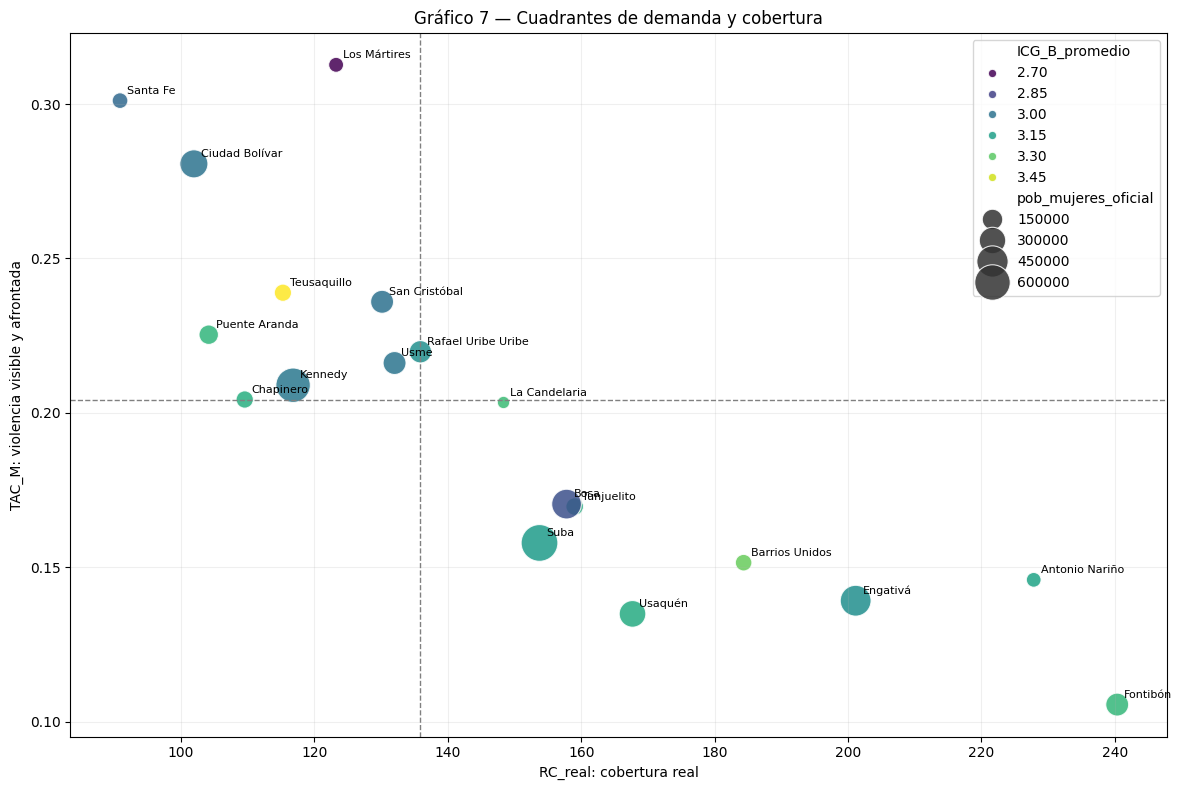

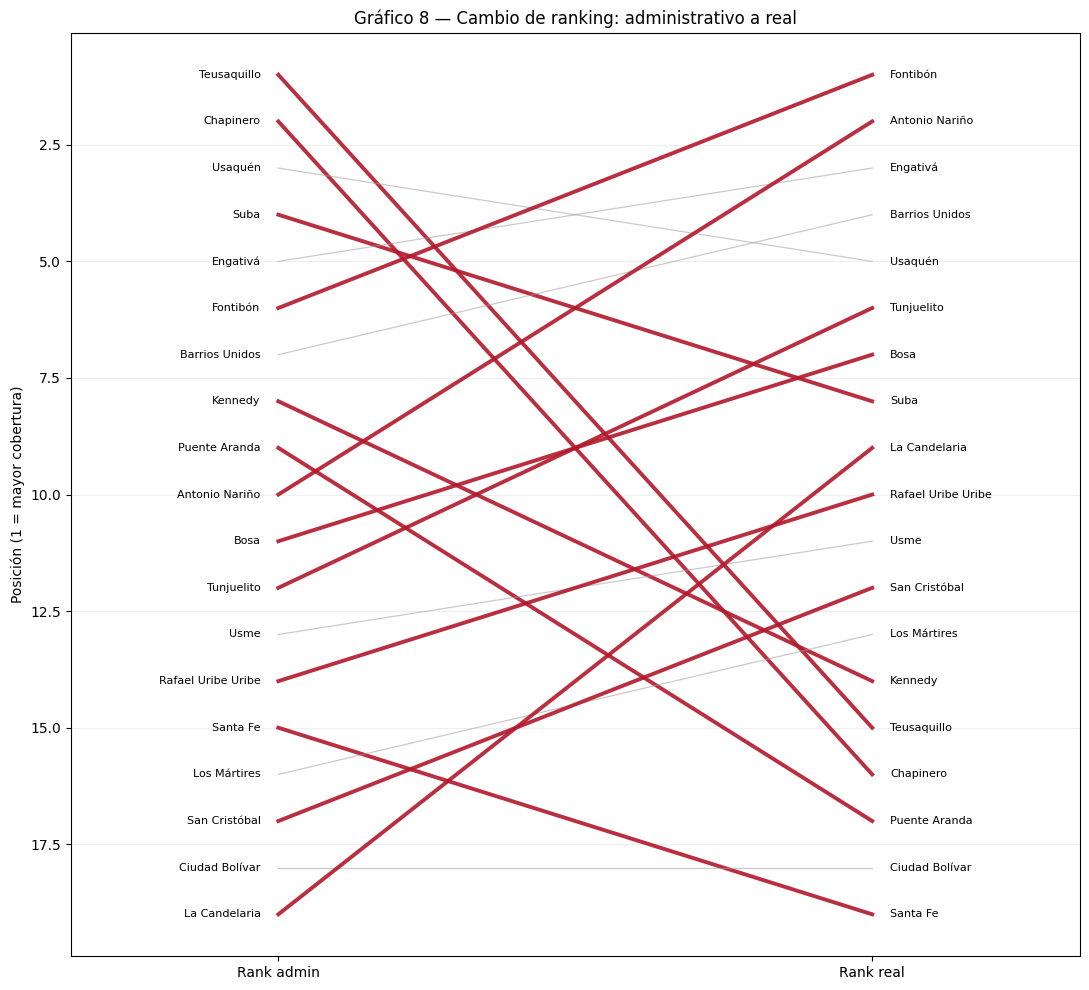

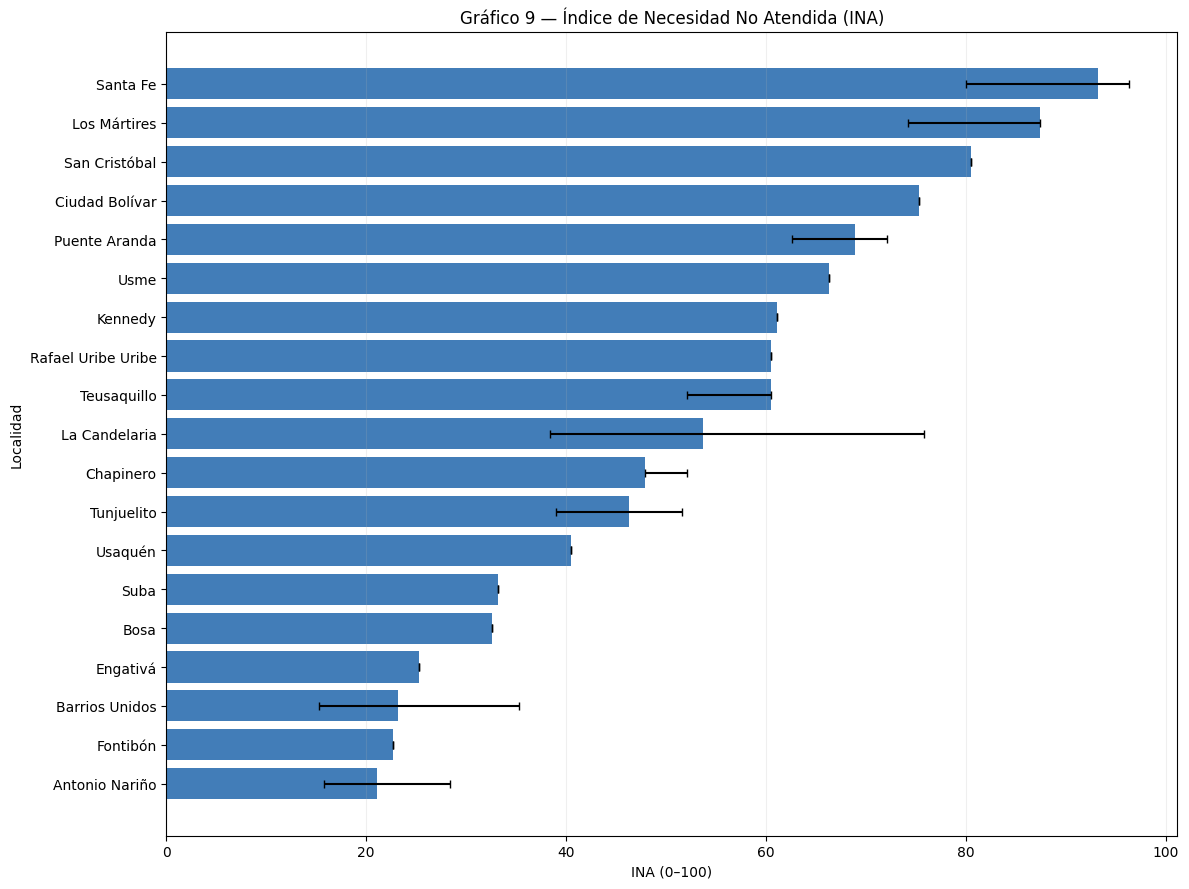

Gráficos 7, 8 y 9 exportados a outputs/tableau


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

RUTA_TABLEAU = Path("../../outputs/tableau")
RUTA_TABLEAU.mkdir(parents=True, exist_ok=True)

# Gráfico 7: dispersión de cuadrantes.
grafico7 = (
    cuadrantes[
        [
            "codigo_localidad",
            "localidad",
            "RC_real_cota_superior",
            "TAC_M",
            "ICG_B_promedio",
            "cuadrante",
        ]
    ]
    .merge(
        admin[["codigo_localidad", "pob_mujeres_oficial"]],
        on="codigo_localidad",
        how="left",
        validate="one_to_one",
    )
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=grafico7,
    x="RC_real_cota_superior",
    y="TAC_M",
    size="pob_mujeres_oficial",
    hue="ICG_B_promedio",
    palette="viridis",
    sizes=(80, 700),
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)
ax.axvline(mediana_cobertura_real, color="gray", linestyle="--", linewidth=1)
ax.axhline(mediana_tac, color="gray", linestyle="--", linewidth=1)
for fila in grafico7.itertuples():
    ax.annotate(
        fila.localidad,
        (fila.RC_real_cota_superior, fila.TAC_M),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_title("Gráfico 7 — Cuadrantes de demanda y cobertura")
ax.set_xlabel("RC_real: cobertura real")
ax.set_ylabel("TAC_M: violencia visible y afrontada")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(
    RUTA_TABLEAU / "grafico7_dispersion_cuadrantes.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

# Gráfico 8: slope chart de rank_admin a rank_real.
grafico8 = fase5[
    ["localidad", "rank_admin", "rank_real", "delta_rank"]
].copy()
grafico8["resaltada"] = grafico8["delta_rank"].abs() >= 4

fig, ax = plt.subplots(figsize=(11, 10))
for fila in grafico8.sort_values("rank_admin").itertuples():
    color = "#b2182b" if fila.resaltada else "#9e9e9e"
    ancho = 2.8 if fila.resaltada else 0.9
    ax.plot(
        [0, 1],
        [fila.rank_admin, fila.rank_real],
        color=color,
        linewidth=ancho,
        alpha=0.9 if fila.resaltada else 0.55,
    )
    ax.text(-0.03, fila.rank_admin, fila.localidad, ha="right", va="center", fontsize=8)
    ax.text(1.03, fila.rank_real, fila.localidad, ha="left", va="center", fontsize=8)
ax.set_xlim(-0.35, 1.35)
ax.set_xticks([0, 1], ["Rank admin", "Rank real"])
ax.invert_yaxis()
ax.set_ylabel("Posición (1 = mayor cobertura)")
ax.set_title("Gráfico 8 — Cambio de ranking: administrativo a real")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(
    RUTA_TABLEAU / "grafico8_slope_rankings.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

# Gráfico 9: INA con incertidumbre disponible en TAC_M e IBA.
grafico9 = resultado_ina[
    [
        "localidad",
        "INA",
        "pct_TAC_M",
        "pct_IBA",
        "pct_deficit_cobertura",
        "rank_INA",
        "TAC_M_ic_inf",
        "TAC_M_ic_sup",
        "IBA_promedio_ic_inf",
        "IBA_promedio_ic_sup",
    ]
].copy()

pct_tac_inf = fase5["TAC_M_ic_inf"].rank(pct=True) * 100
pct_tac_sup = fase5["TAC_M_ic_sup"].rank(pct=True) * 100
pct_iba_inf = fase5["IBA_promedio_ic_inf"].rank(pct=True) * 100
pct_iba_sup = fase5["IBA_promedio_ic_sup"].rank(pct=True) * 100

# Los IC se propagan solo para los componentes con IC disponible.
grafico9["INA_ic_inf"] = (
    PESO_TAC_M * pct_tac_inf
    + PESO_IBA * pct_iba_inf
    + PESO_DEFICIT_COBERTURA * resultado_ina["pct_deficit_cobertura"]
).to_numpy()
grafico9["INA_ic_sup"] = (
    PESO_TAC_M * pct_tac_sup
    + PESO_IBA * pct_iba_sup
    + PESO_DEFICIT_COBERTURA * resultado_ina["pct_deficit_cobertura"]
).to_numpy()
grafico9["error_inf"] = (grafico9["INA"] - grafico9["INA_ic_inf"]).clip(lower=0)
grafico9["error_sup"] = (grafico9["INA_ic_sup"] - grafico9["INA"]).clip(lower=0)
grafico9 = grafico9.sort_values("INA", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(
    grafico9["localidad"],
    grafico9["INA"],
    xerr=[grafico9["error_inf"], grafico9["error_sup"]],
    color="#2166ac",
    alpha=0.85,
    capsize=3,
)
ax.set_title("Gráfico 9 — Índice de Necesidad No Atendida (INA)")
ax.set_xlabel("INA (0–100)")
ax.set_ylabel("Localidad")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(
    RUTA_TABLEAU / "grafico9_ina_componentes_ic.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

grafico9_export = grafico9[
    ["localidad", "INA", "INA_ic_inf", "INA_ic_sup", "rank_INA"]
]
grafico9_export.to_csv(
    "../../outputs/grafico9_ina_componentes_ic.csv",
    index=False,
    encoding="utf-8-sig",
)

texto_resultado_5_12 = """
## Paso 5.12 — Gráficos para dashboard Tableau

- Gráfico 7: dispersión de `RC_real` frente a `TAC_M`, tamaño por población femenina, color por `ICG_B`, líneas de mediana y etiquetas de localidad. Exportado a `outputs/tableau/grafico7_dispersion_cuadrantes.png`.
- Gráfico 8: slope chart de `rank_admin` a `rank_real`, resaltando localidades con `|delta_rank| >= 4`. Exportado a `outputs/tableau/grafico8_slope_rankings.png`.
- Gráfico 9: barras horizontales de INA. Exportado a `outputs/tableau/grafico9_ina_componentes_ic.png`.
- El gráfico 9 propaga únicamente los IC disponibles de `TAC_M` e `IBA`; `RC_real` no tiene IC territorial en la tabla actual, por lo que su contribución se mantiene fija. No debe interpretarse como IC completo del INA.
"""
registrar_resultado(texto_resultado_5_12)
print("Gráficos 7, 8 y 9 exportados a outputs/tableau")